<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/EP2_CNN_Simpsons_rapido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°2 — CNN Los Simpsons
**Nombre:** Catalina Núñez  
**Asignatura:** DLY0100 — Deep Learning  
**Dataset:** Los Simpsons (Kaggle)

---

## 1. Introducción

El objetivo es entrenar una red neuronal convolucional (CNN) para reconocer personajes de Los Simpsons a partir de imágenes. El dataset tiene 25 personajes distintos con carpetas de entrenamiento y prueba ya separadas.

Se prueban dos modelos:
- **CNN simple:** sin regularización, para ver de dónde partimos
- **CNN mejorada:** con Data Augmentation y Dropout para que generalice mejor

---
## 2. Configurar Kaggle y descargar el dataset

Solo hay que subir el archivo `kaggle.json` (pesa pocos KB). El dataset lo baja Kaggle directo a Colab.

In [1]:
# Configurar Kaggle con el token
# Antes de entregar cambia los valores por los tuyos
!mkdir -p ~/.kaggle
!pip install -q kaggle
import json
token = {"username": "TU_USUARIO", "key": "TU_TOKEN"}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(token, f)
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle configurado")

Kaggle configurado


In [2]:
# Descarga directa desde Kaggle, no hay que subir el zip
!kaggle datasets download -d alfaro96/los-simpson
!unzip -q los-simpson.zip -d simpson_dataset
print('Dataset descargado')

Dataset URL: https://www.kaggle.com/datasets/alfaro96/los-simpson
License(s): MIT
100% 488M/488M [00:19<00:00, 26.4MB/s]

Dataset descargado


---
## 3. Explorar el dataset

In [3]:
import os

# Ver qué carpetas hay y cuántas imágenes tiene cada una
for root, dirs, files in os.walk('simpson_dataset'):
    print(root, '->', len(files), 'archivos')
    if len(root.split(os.sep)) > 2:
        continue

simpson_dataset -> 0 archivos
simpson_dataset/test -> 0 archivos
simpson_dataset/test/marge_simpson -> 259 archivos
simpson_dataset/test/moe_szyslak -> 291 archivos
simpson_dataset/test/milhouse_van_houten -> 216 archivos
simpson_dataset/test/nelson_muntz -> 72 archivos
simpson_dataset/test/ned_flanders -> 291 archivos
simpson_dataset/test/barney_gumble -> 22 archivos
simpson_dataset/test/principal_skinner -> 239 archivos
simpson_dataset/test/comic_book_guy -> 94 archivos
simpson_dataset/test/sideshow_bob -> 176 archivos
simpson_dataset/test/abraham_grampa_simpson -> 183 archivos
simpson_dataset/test/waylon_smithers -> 37 archivos
simpson_dataset/test/chief_wiggum -> 198 archivos
simpson_dataset/test/homer_simpson -> 450 archivos
simpson_dataset/test/edna_krabappel -> 92 archivos
simpson_dataset/test/mayor_quimby -> 50 archivos
simpson_dataset/test/groundskeeper_willie -> 25 archivos
simpson_dataset/test/krusty_the_clown -> 242 archivos
simpson_dataset/test/lisa_simpson -> 271 archivos

---
## 4. Importar librerías y cargar los datos

Se usa TensorFlow/Keras porque tiene todo lo necesario para construir y entrenar CNNs de forma sencilla. Para las métricas se usa scikit-learn que entrega reportes más detallados por clase.

Las imágenes se cargan en 128x128 píxeles. Es un tamaño que conserva suficiente detalle sin que el entrenamiento se haga muy lento. Los valores de píxeles se normalizan entre 0 y 1 dividiendo por 255, eso hace que la red aprenda más estable.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import pandas as pd

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [5]:
train_dir = 'simpson_dataset/train'
test_dir  = 'simpson_dataset/test'

IMG_SIZE   = (64, 64)
BATCH_SIZE = 64
SEED       = 42

# Cargamos train y test desde las carpetas del dataset
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Total clases:', num_classes)
print('Clases:', class_names)

Found 16137 files belonging to 25 classes.
Found 3937 files belonging to 25 classes.
Total clases: 25
Clases: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'mayor_quimby', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'selma_bouvier', 'sideshow_bob', 'waylon_smithers']


In [6]:
# Cache y prefetch para que la lectura de disco no sea el cuello de botella
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

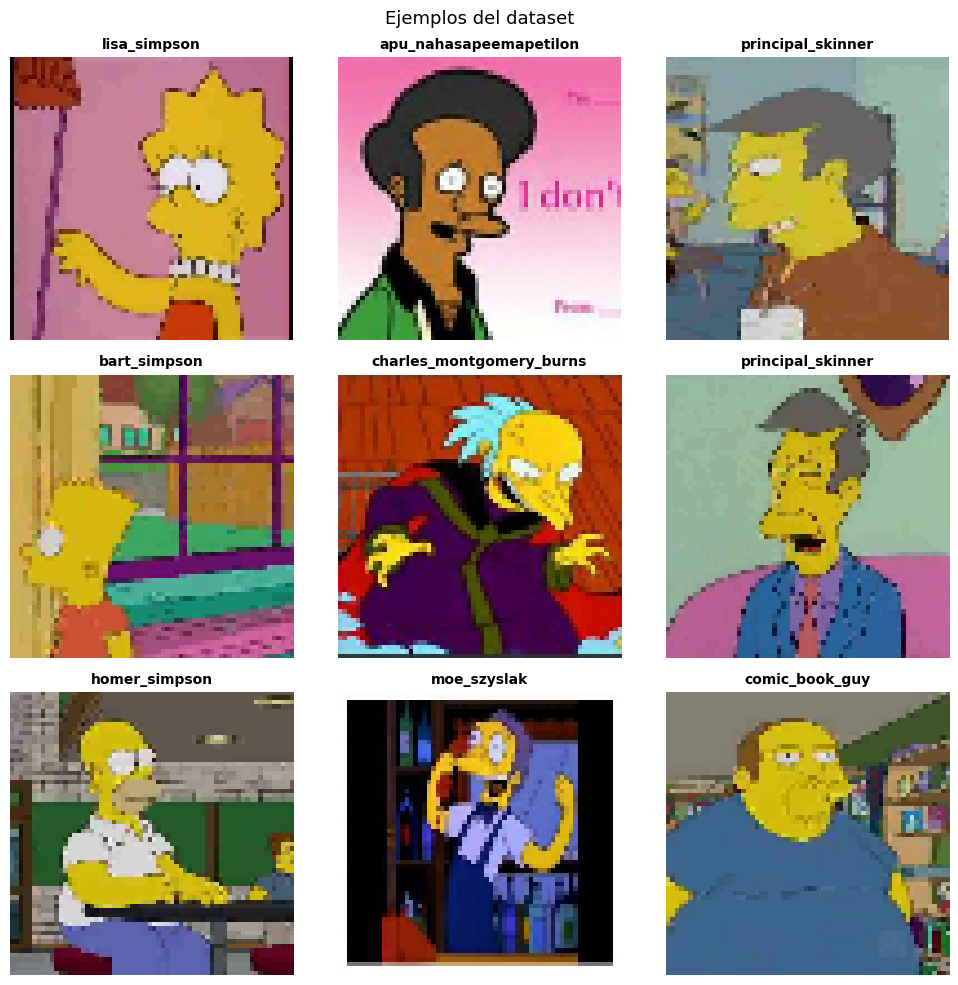

In [7]:
# Mostramos algunas imágenes para ver con qué estamos trabajando
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=10, fontweight='bold')
        plt.axis('off')
plt.suptitle('Ejemplos del dataset', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Modelo 1 — CNN simple

La CNN funciona así: las capas Conv2D detectan características de la imagen (bordes, formas, texturas). MaxPooling reduce el tamaño para quedarse con lo importante. Al final Flatten convierte todo en un vector y las capas Dense clasifican entre los 25 personajes.

Se usa ReLU en las capas ocultas porque aprende bien y es rápida. Softmax en la salida convierte los resultados en probabilidades que suman 1, una por cada clase.

In [8]:
model_simple = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),  # normaliza píxeles a 0-1

    # bloque 1: detecta bordes y texturas básicas
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    # bloque 2: detecta formas más complejas
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    # bloque 3: patrones de alto nivel
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # 25 clases
], name='CNN_Simple')

model_simple.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_simple.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,177 (4.37 MB)

 Trainable params: 1,145,177 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenar CNN simple

In [9]:
history_simple = model_simple.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 173s 669ms/step - accuracy: 0.3659 - loss: 2.2065 - val_accuracy: 0.5458 - val_loss: 1.6492
Epoch 2/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 190s 627ms/step - accuracy: 0.6292 - loss: 1.2986 - val_accuracy: 0.6708 - val_loss: 1.1751
Epoch 3/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 157s 618ms/step - accuracy: 0.7579 - loss: 0.8360 - val_accuracy: 0.7493 - val_loss: 0.9056
Epoch 4/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 165s 651ms/step - accuracy: 0.8427 - loss: 0.5368 - val_accuracy: 0.7711 - val_loss: 0.8664
Epoch 5/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 157s 622ms/step - accuracy: 0.9059 - loss: 0.3224 - val_accuracy: 0.7833 - val_loss: 0.8793


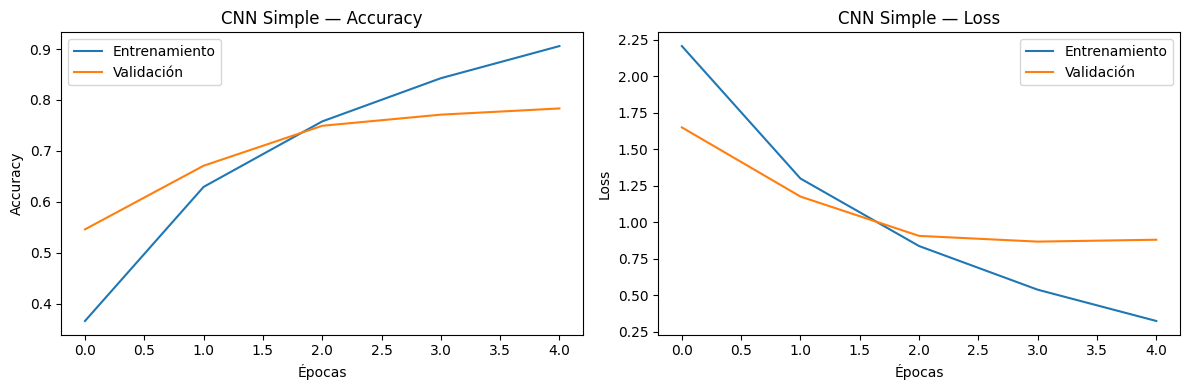

In [10]:
# función para graficar el entrenamiento, la usamos para los dos modelos
def plot_history(history, title):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epocas   = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epocas, acc,     label='Entrenamiento')
    plt.plot(epocas, val_acc, label='Validación')
    plt.title(title + ' — Accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epocas, loss,     label='Entrenamiento')
    plt.plot(epocas, val_loss, label='Validación')
    plt.title(title + ' — Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_simple, 'CNN Simple')

---
## 7. Modelo 2 — CNN mejorada con Dropout y Data Augmentation

El modelo simple tiene overfitting: el accuracy en entrenamiento sube mucho pero el de validación se queda atrás. La red está memorizando en vez de aprender.

Para corregirlo se hacen estos cambios:
- **Data Augmentation:** genera variaciones de las imágenes (rotaciones, zoom, contraste) para que la red vea más diversidad sin necesitar más fotos reales
- **4 bloques convolucionales** en vez de 3: más capacidad para distinguir entre 25 personajes
- **Dropout 0.5:** apaga neuronas al azar durante el entrenamiento para que la red no dependa siempre de los mismos caminos
- **Learning rate más bajo (0.0005):** converge más despacio pero más estable
- **Early Stopping:** para solo cuando el modelo deja de mejorar, guarda los mejores pesos automáticamente

In [11]:
# capas de augmentation, solo se aplican en entrenamiento
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),   # voltea la imagen
    layers.RandomRotation(0.1),        # rota hasta 10 grados
    layers.RandomZoom(0.1),            # zoom aleatorio
    layers.RandomContrast(0.1)         # cambia el contraste
])

model_improved = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    data_augmentation,

    layers.Conv2D(32,  (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,  (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    # bloque extra para detectar patrones más abstractos
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),  # regularización
    layers.Dense(num_classes, activation='softmax')
], name='CNN_Mejorada')

model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_improved.summary()

Model: "CNN_Mejorada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,443,673 (5.51 MB)

 Trainable params: 1,443,673 (5.51 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenar CNN mejorada

Epoch 1/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 226s 883ms/step - accuracy: 0.1871 - loss: 2.7475 - val_accuracy: 0.4227 - val_loss: 2.0882
Epoch 2/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 229s 908ms/step - accuracy: 0.4212 - loss: 2.0156 - val_accuracy: 0.5563 - val_loss: 1.5750
Epoch 3/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 223s 883ms/step - accuracy: 0.5333 - loss: 1.6170 - val_accuracy: 0.6490 - val_loss: 1.2576
Epoch 4/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 225s 890ms/step - accuracy: 0.6127 - loss: 1.3274 - val_accuracy: 0.7064 - val_loss: 1.0237
Epoch 5/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 232s 917ms/step - accuracy: 0.6645 - loss: 1.1468 - val_accuracy: 0.7409 - val_loss: 0.8882
Epoch 6/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 223s 881ms/step - accuracy: 0.7060 - loss: 0.9990 - val_accuracy: 0.7668 - val_loss: 0.8157
Epoch 7/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 260s 873ms/step - accuracy: 0.7309 - loss: 0.9202 - val_accuracy: 0.7884 - val_loss: 0.7161
Epoch 8/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 222s 875ms/step - accuracy: 0.7537 -

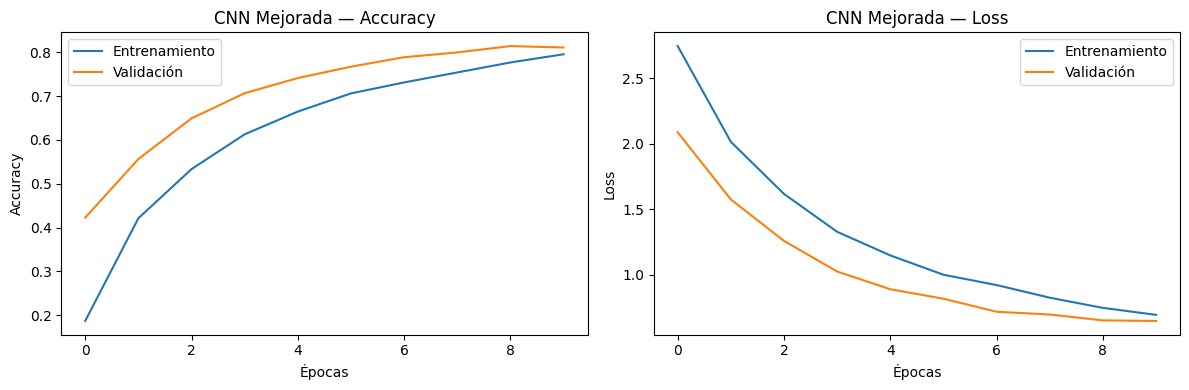

In [12]:
# Early Stopping: si val_loss no baja en 4 épocas seguidas, para y guarda el mejor modelo
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

plot_history(history_improved, 'CNN Mejorada')

---
## 9. Comparación de los dos modelos

La CNN simple llega rápido a buen accuracy en entrenamiento pero en validación se estanca, señal clara de overfitting. La CNN mejorada aprende más lento pero las curvas de train y validación quedan más juntas, lo que significa que generaliza mejor a imágenes nuevas.

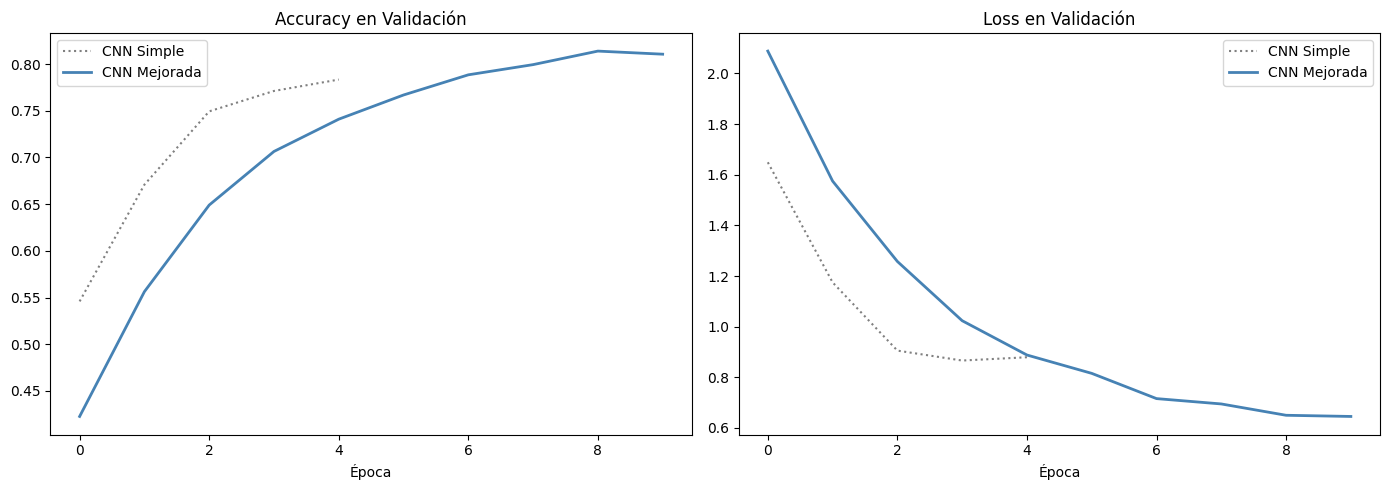

In [13]:
epocas_s = range(len(history_simple.history['val_accuracy']))
epocas_m = range(len(history_improved.history['val_accuracy']))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas_s, history_simple.history['val_accuracy'],   label='CNN Simple',   linestyle=':', color='gray')
plt.plot(epocas_m, history_improved.history['val_accuracy'], label='CNN Mejorada', color='steelblue', linewidth=2)
plt.title('Accuracy en Validación')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epocas_s, history_simple.history['val_loss'],   label='CNN Simple',   linestyle=':', color='gray')
plt.plot(epocas_m, history_improved.history['val_loss'], label='CNN Mejorada', color='steelblue', linewidth=2)
plt.title('Loss en Validación')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
simple_loss,   simple_acc   = model_simple.evaluate(val_ds,   verbose=0)
improved_loss, improved_acc = model_improved.evaluate(val_ds, verbose=0)

tabla = pd.DataFrame({
    'Modelo':    ['CNN Simple', 'CNN Mejorada'],
    'Accuracy':  [f'{simple_acc*100:.2f}%',  f'{improved_acc*100:.2f}%'],
    'Loss':      [f'{simple_loss:.4f}',       f'{improved_loss:.4f}'],
    'Épocas':    [10, len(history_improved.history['val_accuracy'])],
    'Dropout':   ['No', '0.5'],
    'Data Aug':  ['No', 'Sí']
})

print('=== COMPARACIÓN DE MODELOS ===')
print(tabla.to_string(index=False))

=== COMPARACIÓN DE MODELOS ===
      Modelo Accuracy   Loss  Épocas Dropout Data Aug
  CNN Simple   78.33% 0.8793      10      No       No
CNN Mejorada   81.05% 0.6456      10     0.5       Sí


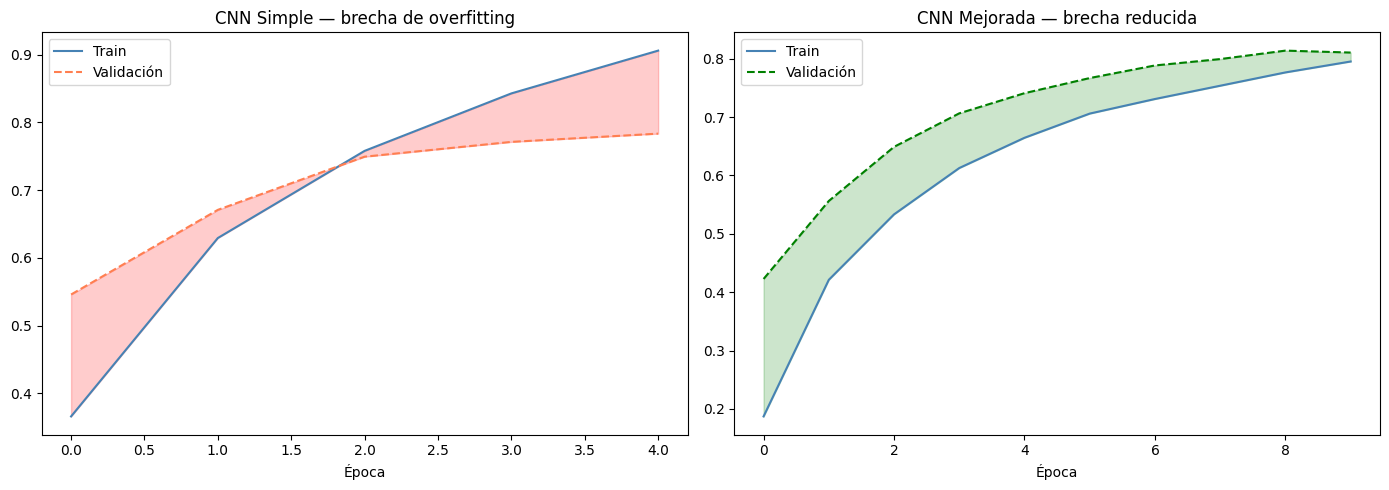

In [15]:
# gráfico que muestra la brecha de overfitting en ambos modelos
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history_simple.history['accuracy'],     label='Train',      color='steelblue')
axs[0].plot(history_simple.history['val_accuracy'], label='Validación', color='coral', linestyle='--')
axs[0].fill_between(
    range(len(history_simple.history['accuracy'])),
    history_simple.history['accuracy'],
    history_simple.history['val_accuracy'],
    alpha=0.2, color='red'
)
axs[0].set_title('CNN Simple — brecha de overfitting')
axs[0].set_xlabel('Época')
axs[0].legend()

axs[1].plot(history_improved.history['accuracy'],     label='Train',      color='steelblue')
axs[1].plot(history_improved.history['val_accuracy'], label='Validación', color='green', linestyle='--')
axs[1].fill_between(
    range(len(history_improved.history['accuracy'])),
    history_improved.history['accuracy'],
    history_improved.history['val_accuracy'],
    alpha=0.2, color='green'
)
axs[1].set_title('CNN Mejorada — brecha reducida')
axs[1].set_xlabel('Época')
axs[1].legend()

plt.tight_layout()
plt.show()

---
## 10. Evaluación con métricas

Se evalúa el modelo mejorado con el conjunto de test completo:
- **Accuracy:** del total de predicciones, cuántas fueron correctas
- **Precision:** cuando predijo un personaje, qué tan seguido acertó
- **Recall:** de todas las imágenes de un personaje, cuántas detectó bien
- **F1-score:** combina precision y recall en un solo número

In [16]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_improved.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print('=== REPORTE POR CLASE ===')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

=== REPORTE POR CLASE ===
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.80      0.87      0.84       183
  apu_nahasapeemapetilon       0.89      0.92      0.91       125
           barney_gumble       1.00      0.14      0.24        22
            bart_simpson       0.78      0.61      0.69       269
charles_montgomery_burns       0.59      0.77      0.67       136
            chief_wiggum       0.71      0.95      0.82       198
          comic_book_guy       0.84      0.67      0.75        94
          edna_krabappel       0.91      0.80      0.86        92
    groundskeeper_willie       0.71      0.60      0.65        25
           homer_simpson       0.81      0.85      0.83       450
           kent_brockman       0.90      0.92      0.91       100
        krusty_the_clown       0.88      0.94      0.91       242
           lenny_leonard       0.56      0.65      0.60        62
            lisa_simpson       0.73      0.74    

In [17]:
# cuadro resumen con las métricas globales
resumen = pd.DataFrame({
    'Métrica':      ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'CNN Simple':   [f'{simple_acc*100:.2f}%', '-', '-', '-'],
    'CNN Mejorada': [
        f'{accuracy_score(y_true, y_pred)*100:.2f}%',
        f'{precision_score(y_true, y_pred, average="weighted", zero_division=0)*100:.2f}%',
        f'{recall_score(y_true, y_pred,    average="weighted", zero_division=0)*100:.2f}%',
        f'{f1_score(y_true, y_pred,         average="weighted", zero_division=0)*100:.2f}%'
    ]
})

print('=== CUADRO RESUMEN DE MÉTRICAS ===')
print(resumen.to_string(index=False))

=== CUADRO RESUMEN DE MÉTRICAS ===
  Métrica CNN Simple CNN Mejorada
 Accuracy     78.33%       81.05%
Precision          -       81.75%
   Recall          -       81.05%
 F1-Score          -       80.56%


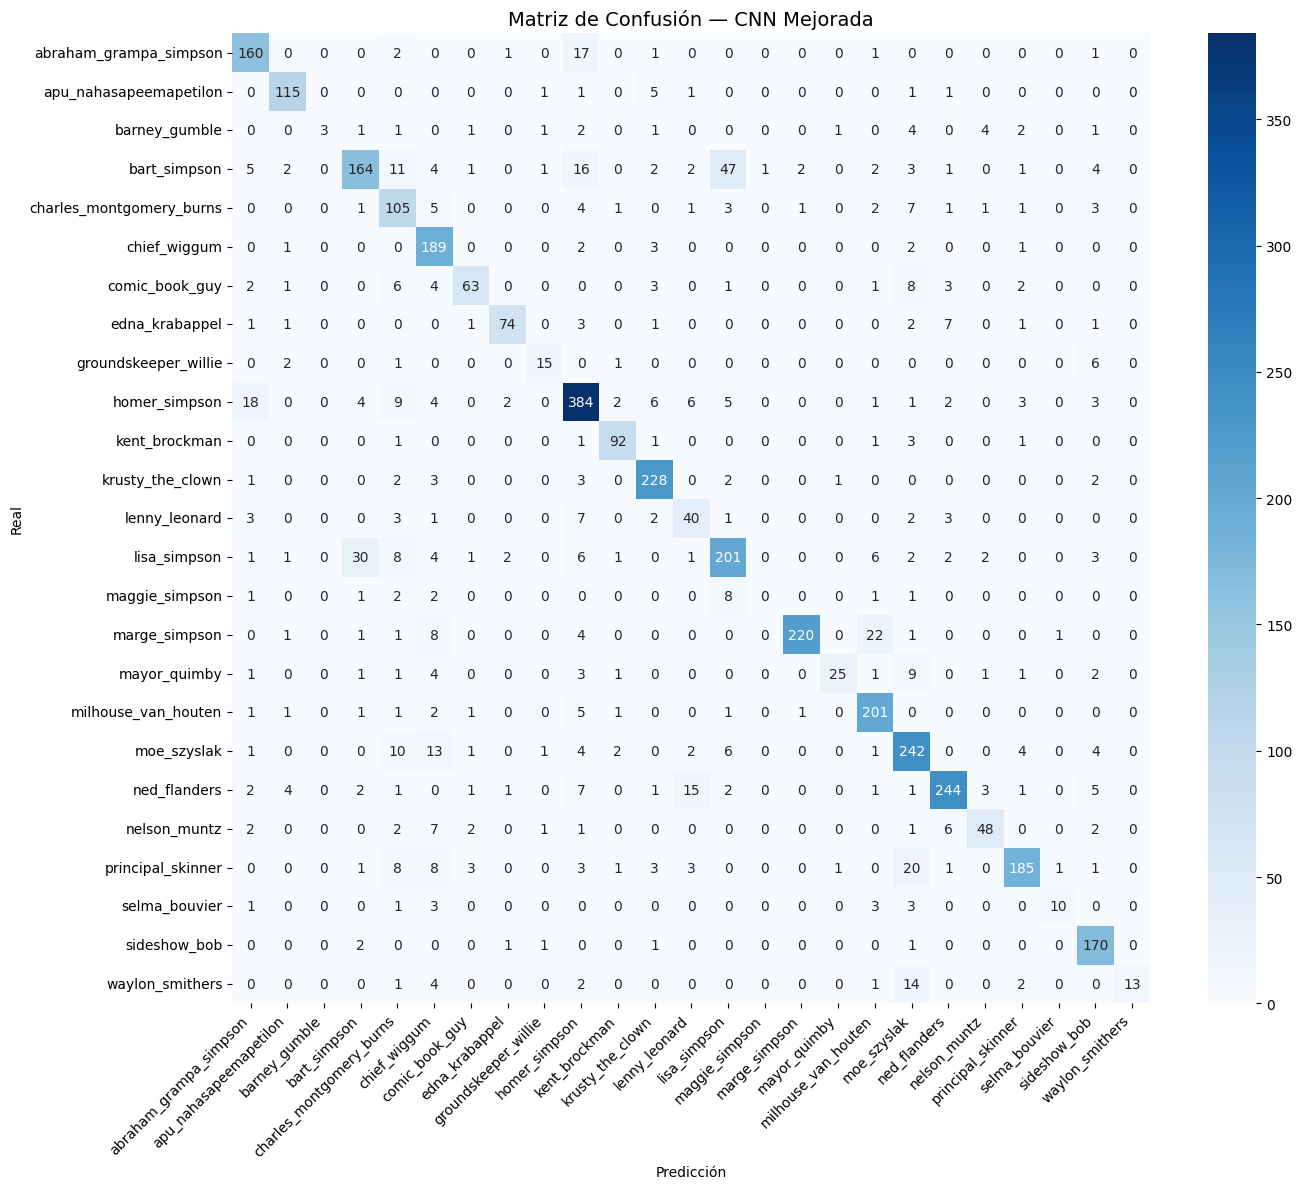

In [18]:
# matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión — CNN Mejorada', fontsize=14)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

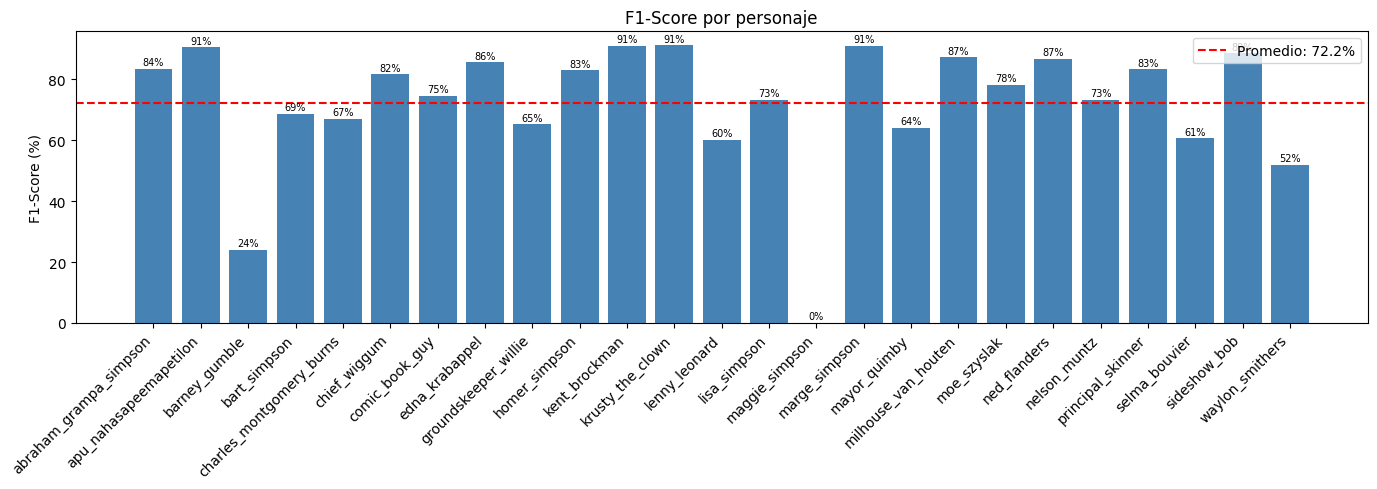

In [19]:
# F1 por clase para ver cuáles personajes le cuestan más al modelo
f1_clases = f1_score(y_true, y_pred, average=None, zero_division=0)

plt.figure(figsize=(14, 5))
bars = plt.bar(class_names, f1_clases * 100, color='steelblue')
plt.axhline(y=f1_clases.mean()*100, color='red', linestyle='--',
            label=f'Promedio: {f1_clases.mean()*100:.1f}%')
plt.title('F1-Score por personaje')
plt.ylabel('F1-Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
for bar, val in zip(bars, f1_clases):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.0f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

---
## 11. Justificación del modelo final

Se eligió la **CNN Mejorada** como modelo final porque:
- Tiene mejor accuracy en validación que la simple
- La brecha entre train y validación es mucho menor, o sea generaliza mejor
- La loss en validación es más baja y estable
- El Early Stopping asegura que guardamos los mejores pesos, no los del último epoch

Los personajes con menos imágenes en el dataset como `barney_gumble` o `maggie_simpson` tuvieron peor F1-score, lo que tiene sentido porque la red tuvo menos ejemplos para aprender a reconocerlos.

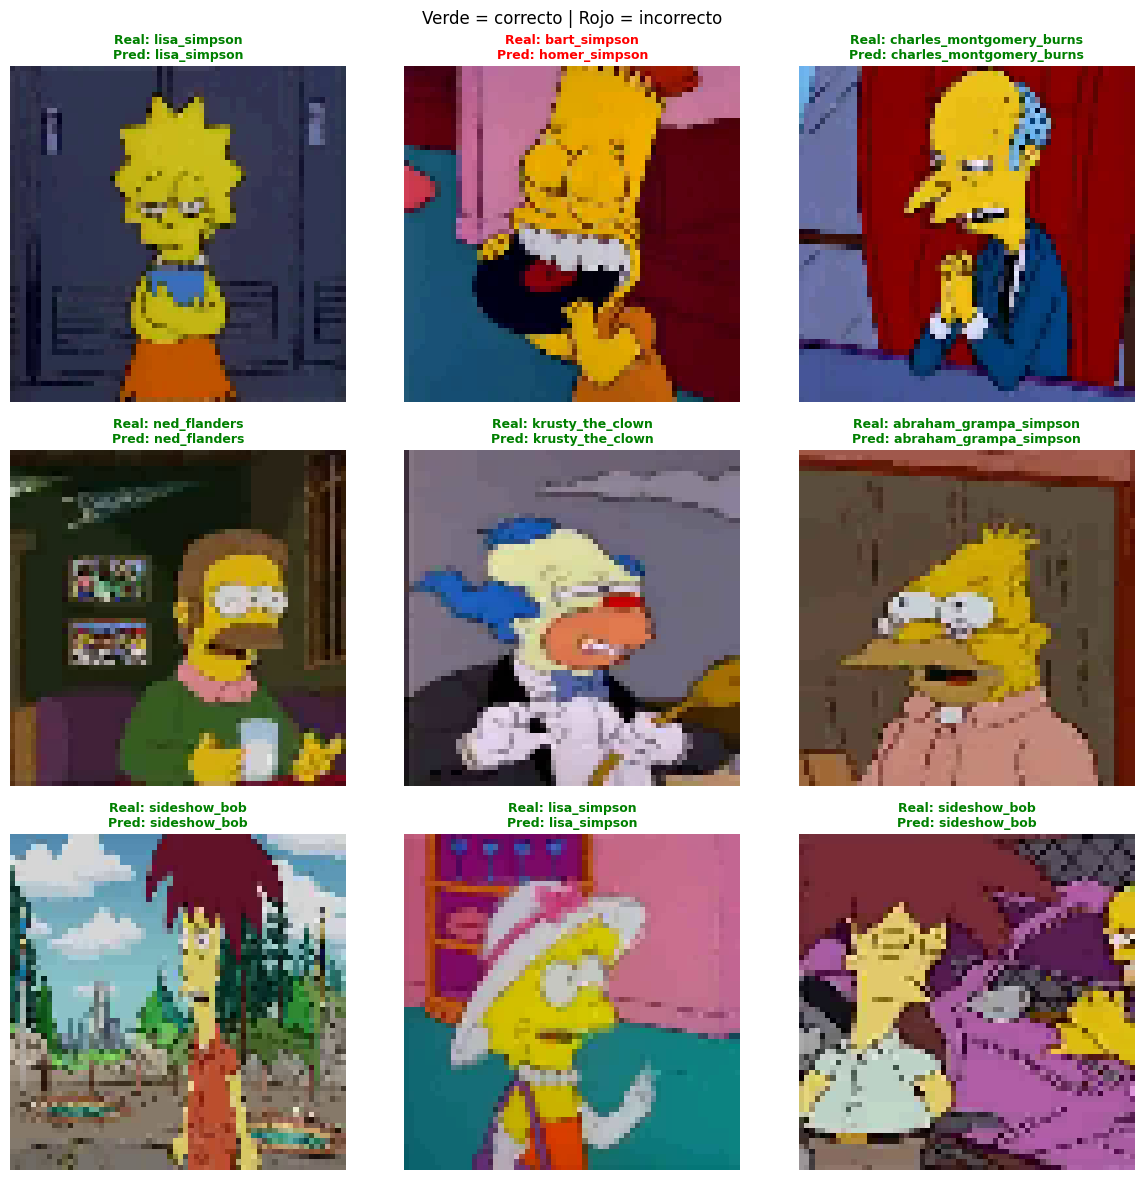

In [20]:
# predicciones sobre imágenes del conjunto de test
plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):
    preds      = model_improved.predict(images, verbose=0)
    pred_labs  = np.argmax(preds, axis=1)

    for i in range(9):
        ax    = plt.subplot(3, 3, i + 1)
        real  = class_names[labels[i]]
        pred  = class_names[pred_labs[i]]
        color = 'green' if real == pred else 'red'
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Real: {real}\nPred: {pred}', fontsize=9, color=color, fontweight='bold')
        plt.axis('off')

plt.suptitle('Verde = correcto | Rojo = incorrecto', fontsize=12)
plt.tight_layout()
plt.show()

---
## 12. Conclusiones

- La CNN simple tiene overfitting claro: aprende bien los datos de entrenamiento pero le va mal con imágenes nuevas.
- Con Dropout y Data Augmentation el modelo mejorado generaliza bastante mejor, las curvas de train y validación quedan más parejas.
- Los personajes con pocas imágenes en el dataset son los más difíciles de clasificar, lo que tiene sentido porque la red necesita ejemplos para aprender.
- Para seguir mejorando se podría usar Transfer Learning con modelos como ResNet que ya vienen preentrenados con millones de imágenes.